In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y
df["class_name"] = df["target"].map({
    0: wine.target_names[0],
    1: wine.target_names[1],
    2: wine.target_names[2]
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
print("Feature names:")
print(wine.feature_names)

print("\nTarget names:")
print(wine.target_names)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["class_name"].value_counts())

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target names:
['class_0' 'class_1' 'class_2']

Missing values in each column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
class_name                      0
dtype: int64

Class distribution:
class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


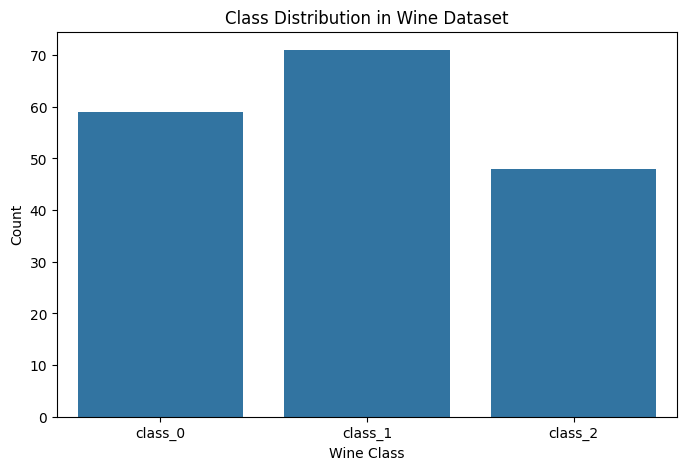

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x="class_name", data=df)
plt.title("Class Distribution in Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

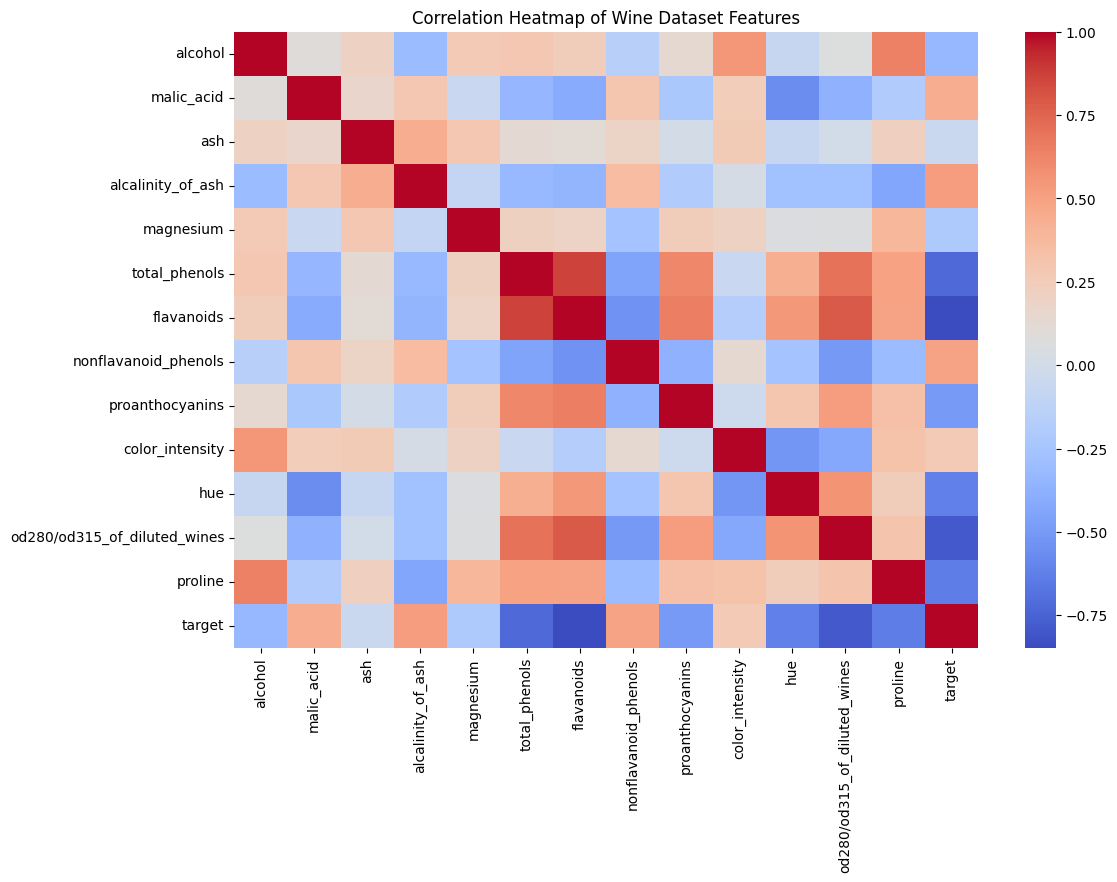

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=["class_name"]).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap of Wine Dataset Features")
plt.show()

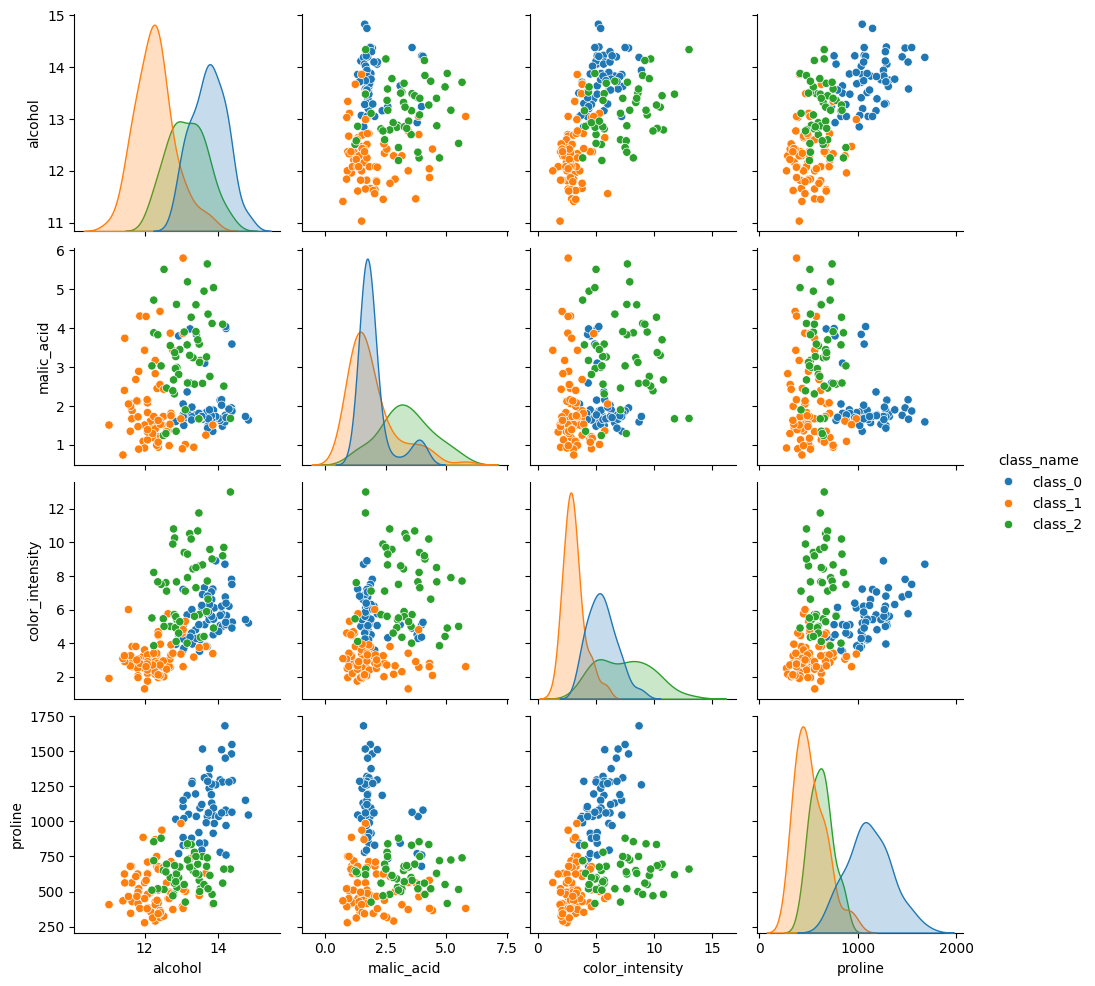

In [7]:
selected_columns = ["alcohol", "malic_acid", "color_intensity", "proline", "class_name"]
sns.pairplot(df[selected_columns], hue="class_name")
plt.show()

In [8]:
X = df[wine.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (142, 13)
Testing set shape: (36, 13)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [10]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [11]:
y_pred = model.predict(X_test_scaled)

print("Predicted classes:")
print(y_pred)

Predicted classes:
[0 1 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 97.22 %


In [13]:
report = classification_report(y_test, y_pred, target_names=wine.target_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



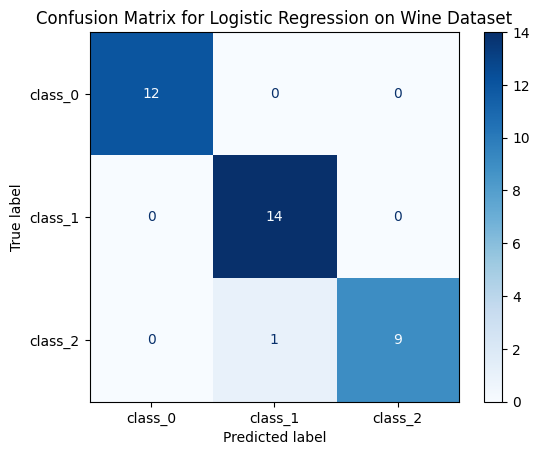

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Logistic Regression on Wine Dataset")
plt.show()

In [15]:
coef_df = pd.DataFrame(
    model.coef_,
    columns=wine.feature_names,
    index=wine.target_names
)

coef_df.T

,class_0,class_1,class_2
alcohol,0.717483,-0.861536,0.144053
malic_acid,0.167605,-0.512162,0.344557
ash,0.460126,-0.807256,0.347130
alcalinity_of_ash,-0.835063,0.466246,0.368817
magnesium,0.038629,-0.143768,0.105138
total_phenols,0.226480,0.062098,-0.288579
flavanoids,0.705264,0.198202,-0.903466
nonflavanoid_phenols,-0.108313,0.110509,-0.002196
proanthocyanins,0.125404,0.370369,-0.495773
color_intensity,0.220184,-1.096016,0.875831


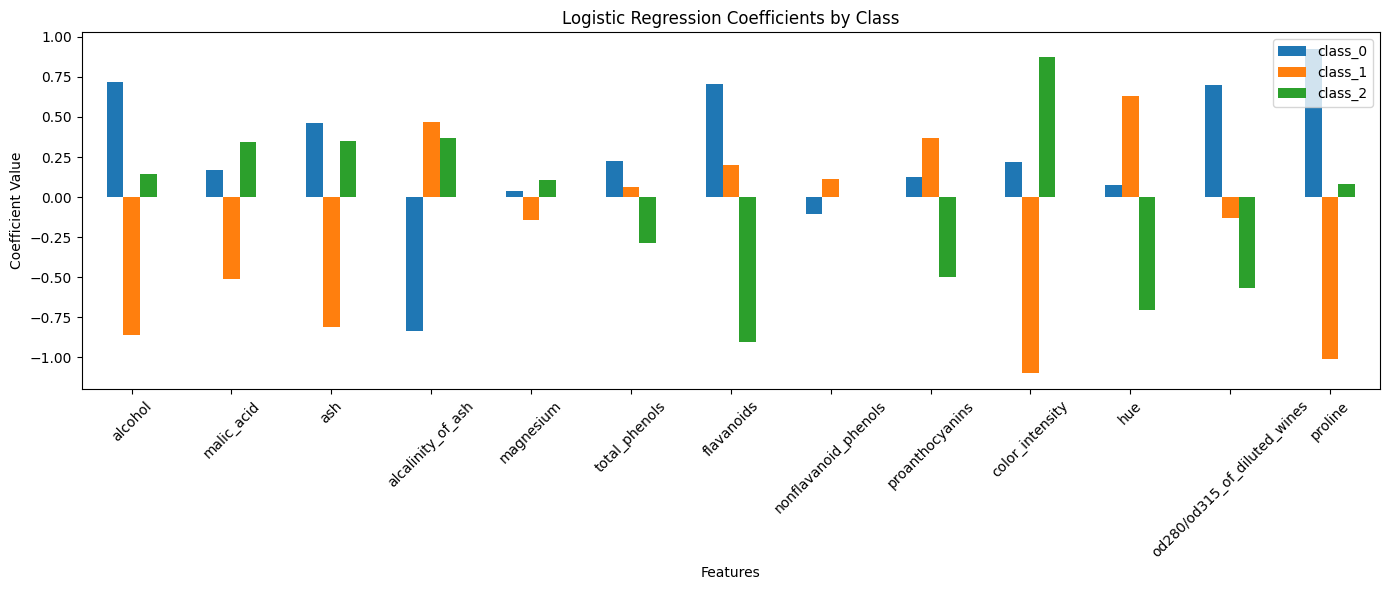

In [16]:
coef_df.T.plot(kind="bar", figsize=(14, 6))
plt.title("Logistic Regression Coefficients by Class")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
print("Final Model Summary")
print("-------------------")
print("Dataset used: Wine Dataset")
print("Algorithm used: Logistic Regression")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Accuracy:", round(accuracy * 100, 2), "%")

Final Model Summary
-------------------
Dataset used: Wine Dataset
Algorithm used: Logistic Regression
Training samples: 142
Testing samples: 36
Accuracy: 97.22 %
